<a href="https://colab.research.google.com/github/eshhha/adult_income_predictions/blob/preprocessing/Muhammed_Naif_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#LIBRARIES

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#READ DATASET

In [3]:
filepath = '/content/drive/MyDrive/AI ML Course/Data/adult.csv'
df_adult = pd.read_csv(filepath)
df_adult

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


#EDA(Exploratory Data Analysis)

In [4]:
# Check the number of rows and columns in the dataset
df_adult.shape

(48842, 15)

In [5]:
# Display summary statistics of the numerical columns
df_adult.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
# Display information about the DataFrame
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [7]:
# Count the occurrences of each unique row in the DataFrame
df_adult.value_counts()

age  workclass  fnlwgt  education     educational-num  marital-status      occupation         relationship   race   gender  capital-gain  capital-loss  hours-per-week  native-country  income
25   Private    308144  Bachelors     13               Never-married       Craft-repair       Not-in-family  White  Male    0             0             40              Mexico          <=50K     3
                195994  1st-4th       2                Never-married       Priv-house-serv    Not-in-family  White  Female  0             0             40              Guatemala       <=50K     3
21   Private    243368  Preschool     1                Never-married       Farming-fishing    Not-in-family  White  Male    0             0             50              Mexico          <=50K     3
39   Private    184659  HS-grad       9                Married-civ-spouse  Machine-op-inspct  Husband        White  Male    0             0             40              United-States   <=50K     2
45   Private    82797   Bachelors     13               Married-civ-spouse  Exec-managerial    Husband        White  Male    0             0             45              United-States   >50K      2
                                                                                                                                                                                                 ..
31   Private    156464  10th          6                Divorced            Other-service      Not-in-family  White  Male    0             0             40              United-States   <=50K     1
                        Bachelors     13               Never-married       Prof-specialty     Own-child      White  Male    0             0             25              United-States   <=50K     1
                156493  HS-grad       9                Never-married       Prof-specialty     Own-child      White  Male    0             0             40              United-States   <=50K     1
                        Some-college  10               Married-civ-spouse  Exec-managerial    Husband        White  Male    0             0             40              United-States   >50K      1
                152940  Some-college  10               Married-civ-spouse  Craft-repair       Husband        White  Male    0             0             40              United-States   <=50K     1
Name: count, Length: 48790, dtype: int64

In [8]:
# Count the total number of duplicate rows in the DataFrame
df_adult.duplicated().sum()

np.int64(52)

In [9]:
# Count the number of missing values in each column
df_adult.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


##PLOTS

In [10]:
# collecting numerical columns
num_cols = []
# collecting categorical columns
cat_cols = []

In [11]:
# Select the names of all numerical columns (integer and float data types)
num_cols = df_adult.select_dtypes(include=['int','float']).columns
# Select the names of all categorical columns (object and boolean data types)
cat_cols = df_adult.select_dtypes(include=['object','bool']).columns

In [12]:
# Display the names of the numerical columns
num_cols

Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [13]:
# Display the names of the categorical columns
cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country', 'income'],
      dtype='object')

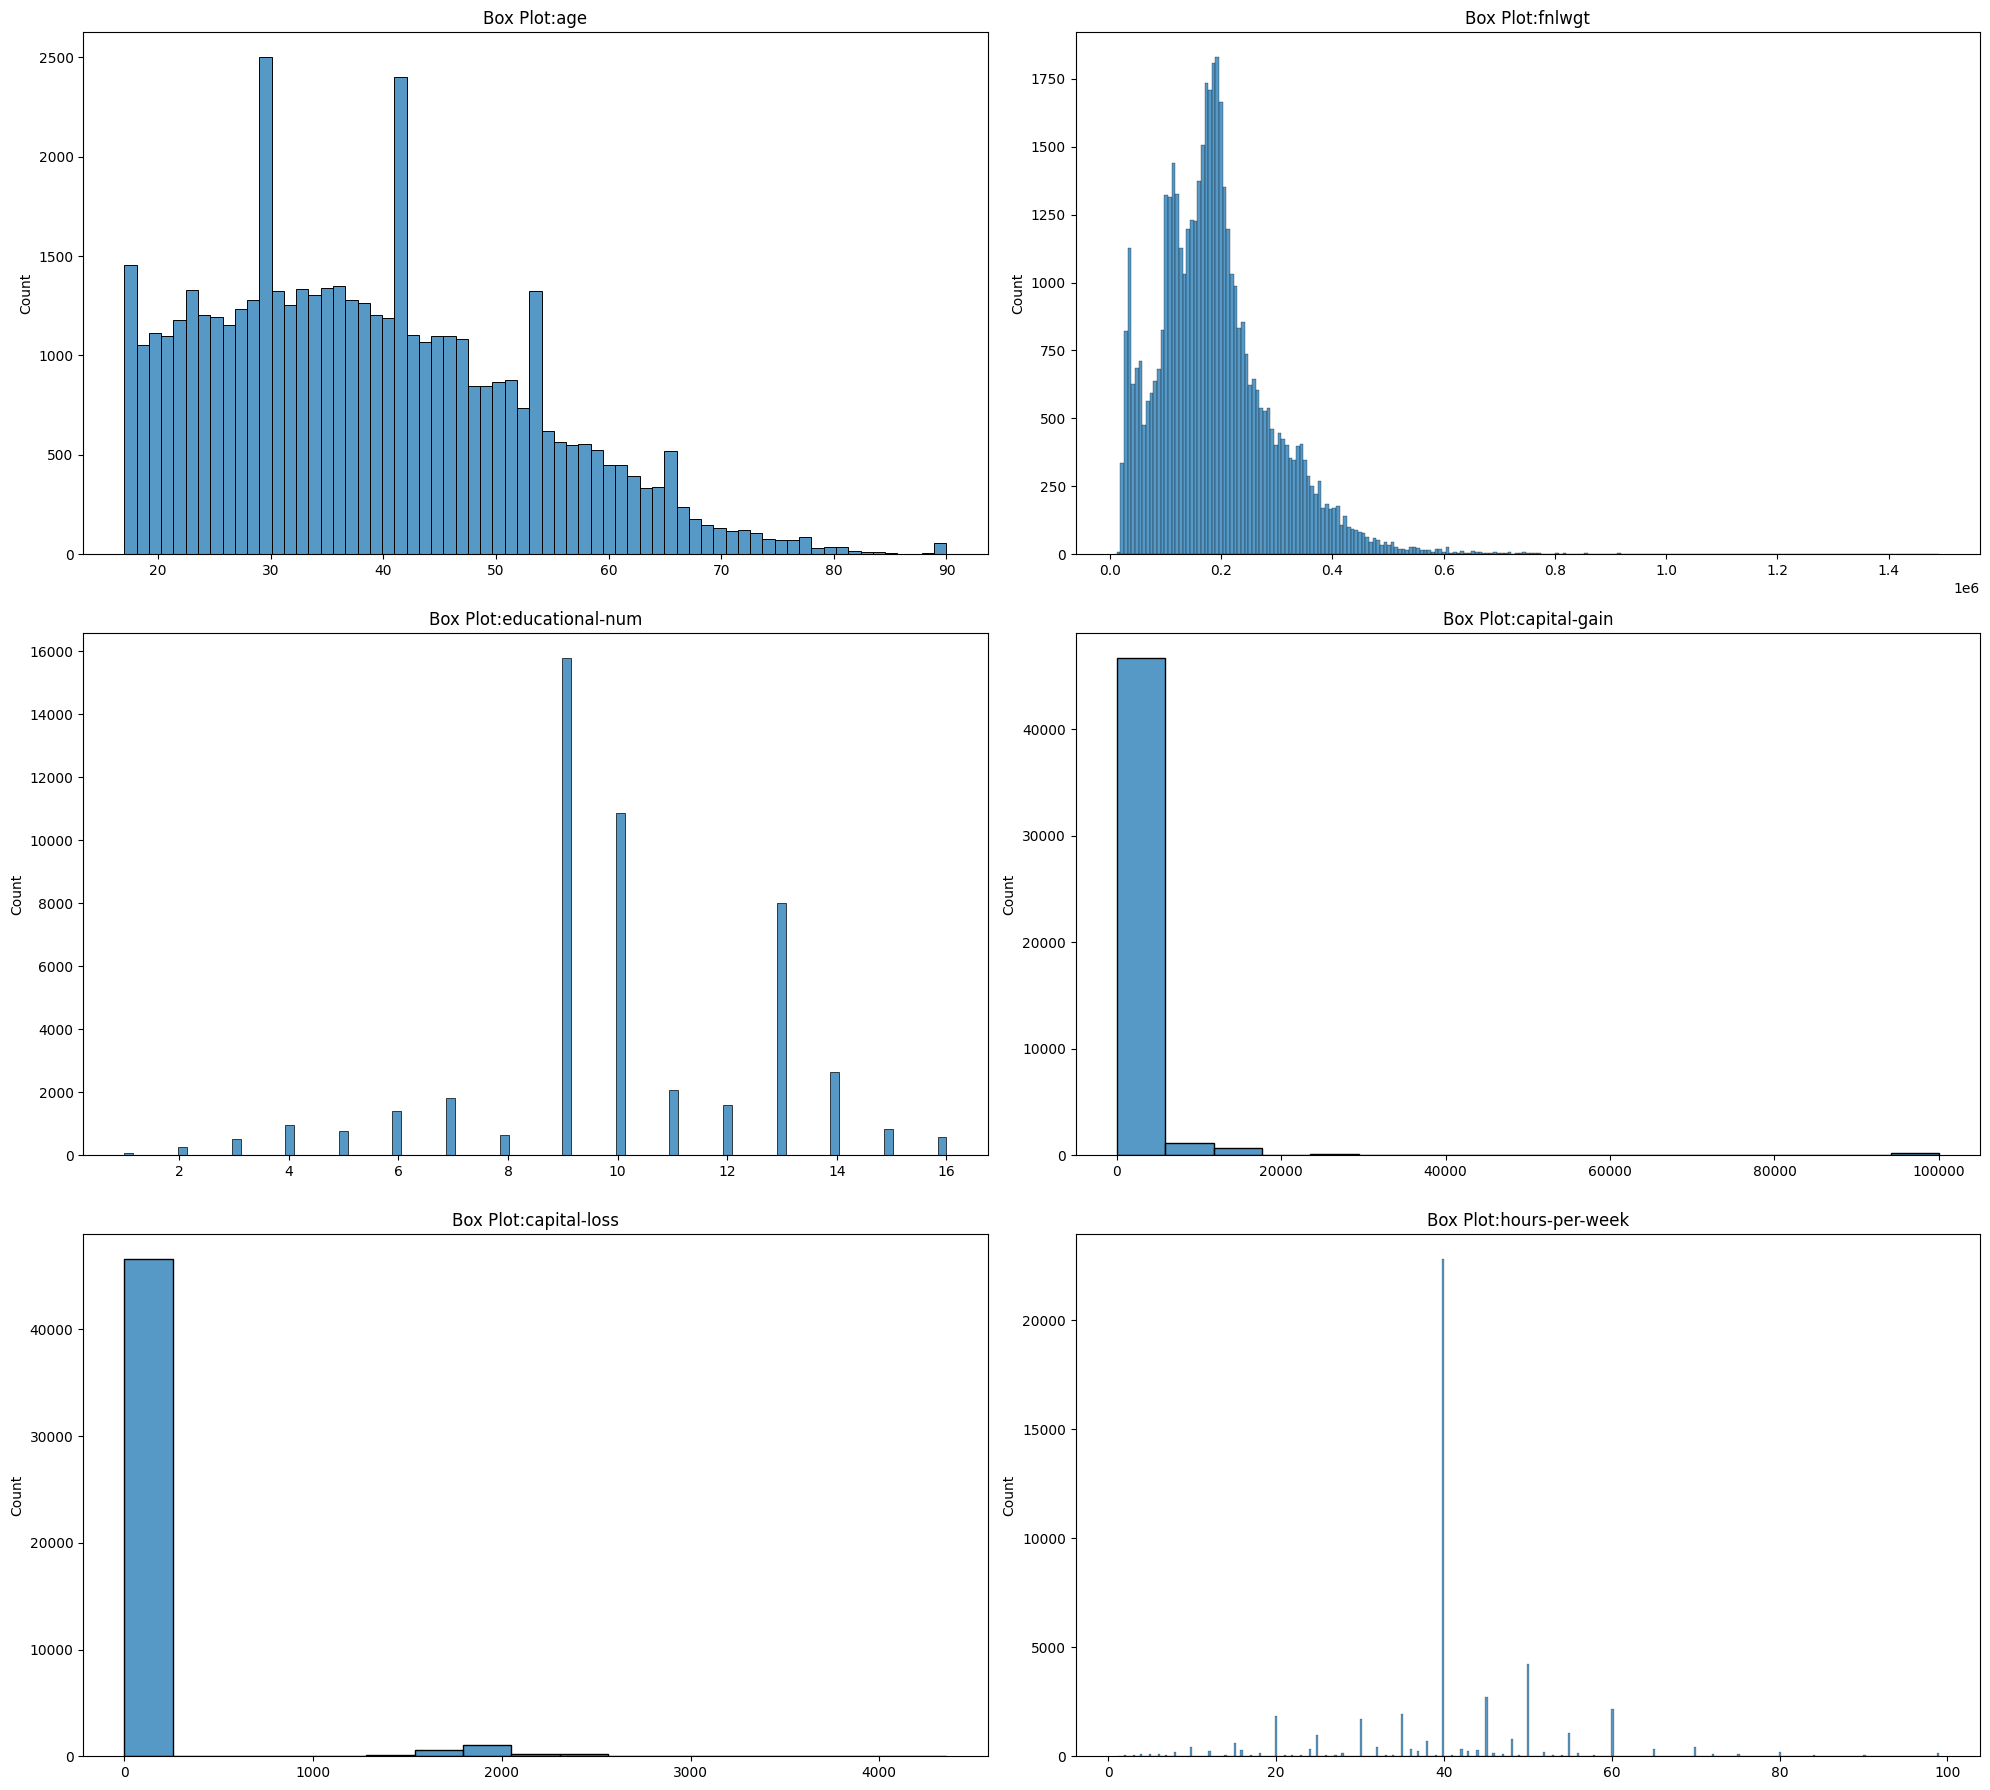

In [14]:
# Create histograms for each numerical column to understand the distribution of values
plt.figure(figsize=(20,18))

for i,col in enumerate(num_cols):
  plt.subplot(3,2,i+1)
  sns.histplot(df_adult[col])
  plt.title(f'Box Plot:{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

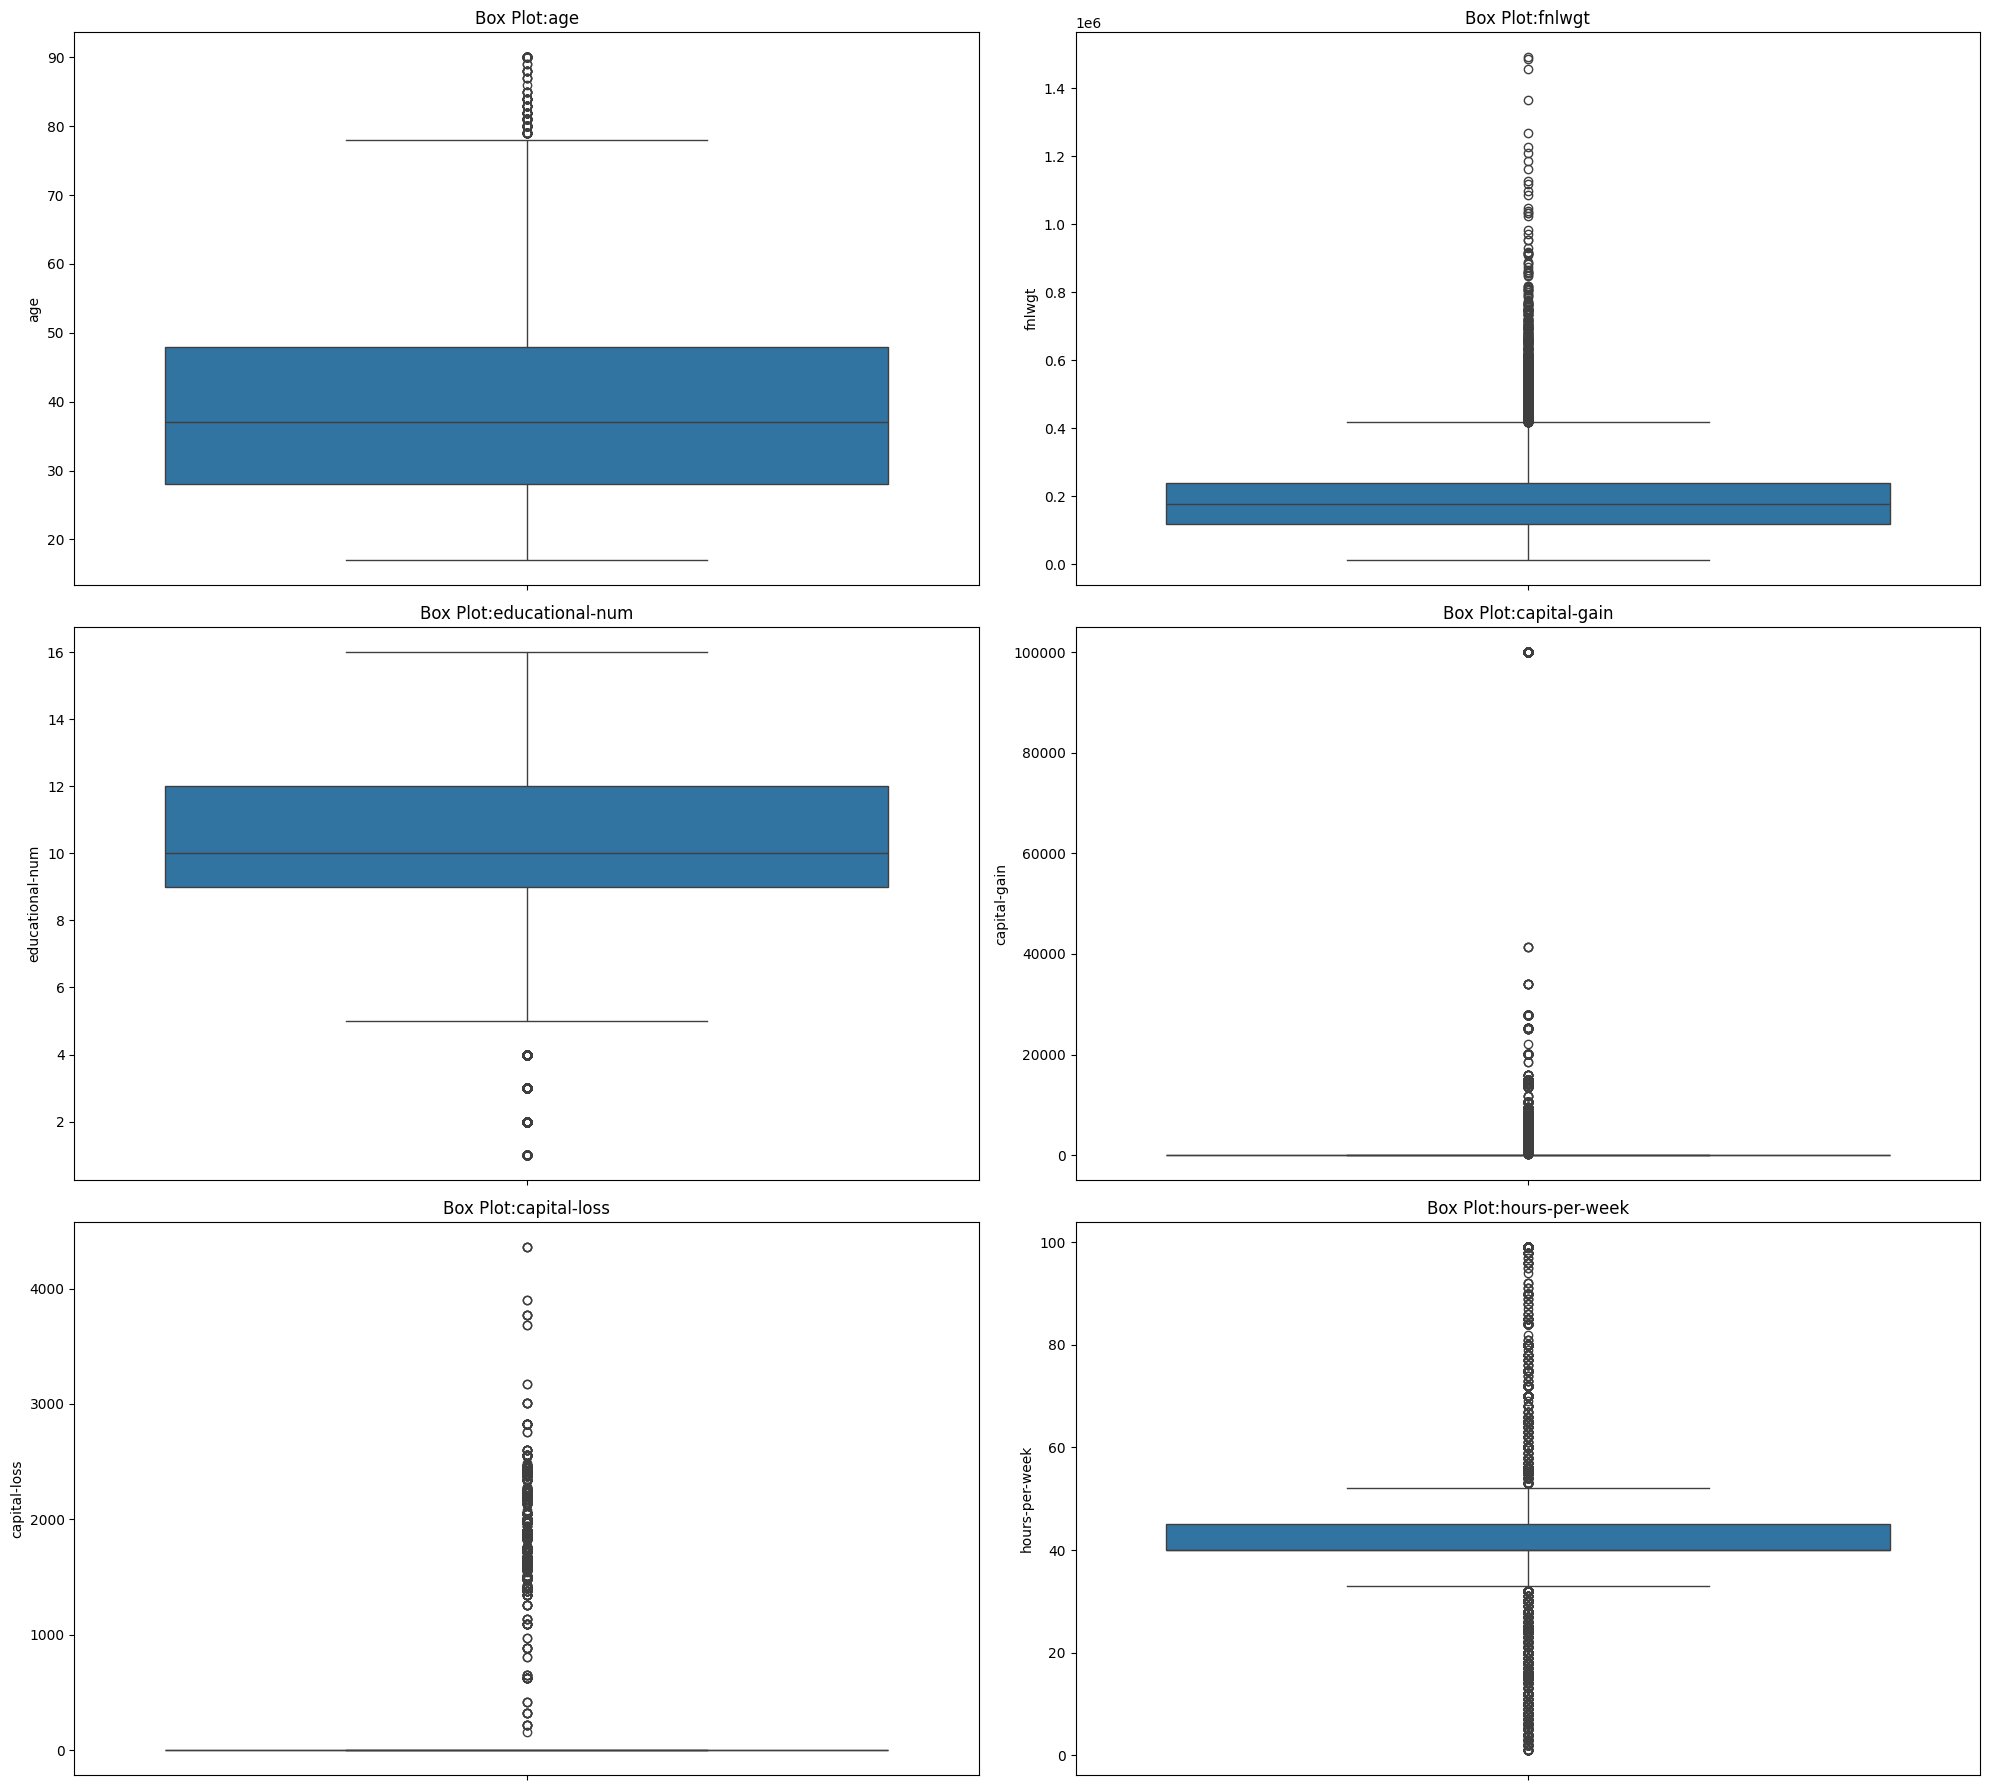

In [15]:
# Create box plots for all numerical features to detect potential outliers
plt.figure(figsize=(20,18))

for i,col in enumerate(num_cols):
  plt.subplot(3,2,i+1)
  sns.boxplot(df_adult[col])
  plt.title(f'Box Plot:{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

#PREPROCESSING
## By: Muhammed_Naif_s

##Data Cleaning

In [16]:
# Observation from EDA:
# df_adult.isna().sum()` showed 0 missing values.

# Hypothesis:
# The dataset may use "?" strings to represent missing values
# instead of standard NaN, causing pandas to miss them.

# Approach:
# 1. Verify if "?" exists in the data
# 2. If yes, convert them to NaN
# 3. Analyze the missing pattern
# 4. Decide filling strategy
# 5. Apply and verify

###Missing Value Handling

In [18]:
for column in df_adult.columns:
    # Only check object (text) columns
    if df_adult[column].dtype == 'object':
        # Count "?" occurrences
        question_count = (df_adult[column] == '?').sum()

        # Only print if "?" found
        if question_count > 0:
            print(f"{column}: {question_count} '?' values found")

workclass: 2799 '?' values found
occupation: 2809 '?' values found
native-country: 857 '?' values found


In [20]:
# Now that we confirmed "?" exists, replace them with NaN
# This allows pandas to detect them as proper missing values

# Replace all "?" values with NaN across entire DataFrame
df_adult = df_adult.replace('?', np.nan)

In [21]:
# --- Verify conversion worked ---
# Check missing values using standard method now

# Get counts of missing values
missing_counts = df_adult.isna().sum()

In [22]:
# Show only columns WITH missing values
missing_counts = missing_counts[missing_counts > 0]
print(missing_counts)

workclass         2799
occupation        2809
native-country     857
dtype: int64


In [23]:
# Calculate percentage

missing_percent = (missing_counts / len(df_adult)) * 100
print(missing_percent.round(2))

workclass         5.73
occupation        5.75
native-country    1.75
dtype: float64


In [24]:
# Show mode values for context
for col in ['workclass', 'occupation', 'native-country']:
    mode_val = df_adult[col].mode()[0]
    mode_count = (df_adult[col] == mode_val).sum()
    mode_pct = (mode_count / df_adult[col].notna().sum()) * 100

    print(f"{col}:")
    print(f"  Mode value: '{mode_val}'")
    print(f"  Represents: {mode_pct:.1f}% of non-missing data")
    print()

workclass:
  Mode value: 'Private'
  Represents: 73.6% of non-missing data

occupation:
  Mode value: 'Prof-specialty'
  Represents: 13.4% of non-missing data

native-country:
  Mode value: 'United-States'
  Represents: 91.3% of non-missing data



I am using a data-driven decision. When the
mode represents a strong majority (over 70%),
using mode is safe as it reflects the true
dominant category. However, for occupation,
the mode 'Prof-specialty' only represents
13.4% of data. Filling 2,809 missing values
with it would artificially inflate this
category, distorting the distribution.
Instead, I used 'Unknown' to preserve the
information that data was missing without
biasing the model.

In [25]:
# Fill workclass with mode
workclass_mode = df_adult['workclass'].mode()[0]
df_adult['workclass'].fillna(workclass_mode, inplace=True)
print(f"✅ workclass filled with mode: '{workclass_mode}'")

✅ workclass filled with mode: 'Private'


/tmp/ipykernel_612/503337042.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_adult['workclass'].fillna(workclass_mode, inplace=True)


In [26]:
# ill occupation with "Unknown"
df_adult['occupation'].fillna('Unknown', inplace=True)
print(f"✅ occupation filled with 'Unknown'")

✅ occupation filled with 'Unknown'


/tmp/ipykernel_612/3959700360.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_adult['occupation'].fillna('Unknown', inplace=True)


In [27]:
# Fill native-country with mode
country_mode = df_adult['native-country'].mode()[0]
df_adult['native-country'].fillna(country_mode, inplace=True)
print(f"✅ native-country filled with mode: '{country_mode}'")

✅ native-country filled with mode: 'United-States'


/tmp/ipykernel_612/893438321.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_adult['native-country'].fillna(country_mode, inplace=True)


In [28]:
# Final Verification
total_missing = df_adult.isna().sum().sum()
print(f"Total missing values remaining: {total_missing}")


--- Final Missing Values Check ---
Total missing values remaining: 0


##Duplication Removal

In [29]:
current_duplicates = df_adult.duplicated().sum()
current_rows = df_adult.shape[0]

print(f"Current rows: {current_rows}")
print(f"Duplicate rows: {current_duplicates}")
print(f"Unique rows: {current_rows - current_duplicates}")

Current rows: 48842
Duplicate rows: 52
Unique rows: 48790


In [31]:
# --- Remove Duplicate Rows ---
# Strategy: keep='first' → keeps first occurrence, removes others
# Reason: Duplicates add bias; only 52 rows (0.1% loss) is acceptable

In [32]:
# Show before state
print(f"Rows BEFORE removal: {df_adult.shape[0]}")

Rows BEFORE removal: 48842


In [33]:
# Remove duplicates
df_adult = df_adult.drop_duplicates(keep='first')

In [34]:
# Show after state
print(f"Rows AFTER removal: {df_adult.shape[0]}")
print(f"Duplicates removed: {52}")

Rows AFTER removal: 48790
Duplicates removed: 52


In [35]:
# Verify no duplicates remain
remaining_duplicates = df_adult.duplicated().sum()
print(f"\nRemaining duplicates: {remaining_duplicates}")


Remaining duplicates: 0


###Outlier Handling

In [36]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    count = len(outliers)
    percentage = (count / len(df)) * 100

    return count, lower_bound, upper_bound, percentage

In [37]:
# --- Numerical columns to check ---
numerical_cols = ['age', 'fnlwgt', 'educational-num',
                  'capital-gain', 'capital-loss', 'hours-per-week']

In [38]:
# --- Detect outliers in each column ---
print("--- Outlier Detection Report ---\n")
print(f"{'Column':<20} {'Outliers':<10} {'% of Data':<12} {'Lower':<15} {'Upper':<15}")
print("-" * 72)

for col in numerical_cols:
    count, lower, upper, pct = detect_outliers_iqr(df_adult, col)
    print(f"{col:<20} {count:<10} {pct:<12.2f} {lower:<15.2f} {upper:<15.2f}")

--- Outlier Detection Report ---

Column               Outliers   % of Data    Lower           Upper          
------------------------------------------------------------------------
age                  215        0.44         -2.00           78.00          
fnlwgt               1453       2.98         -62521.88       417683.12      
educational-num      1787       3.66         4.50            16.50          
capital-gain         4035       8.27         0.00            0.00           
capital-loss         2282       4.68         0.00            0.00           
hours-per-week       13486      27.64        32.50           52.50          


In [39]:
# Outlier Handling: Cap Using IQR Method
# Strategy: Cap outliers in columns where IQR gives valid bounds
# Skip: capital-gain and capital-loss (zero-inflated, IQR returns 0-0)

In [40]:
# Columns where capping makes sense
cap_columns = ['age', 'fnlwgt', 'educational-num', 'hours-per-week']

In [41]:
# Loop through each column and cap outliers
for col in cap_columns:
    # Calculate IQR bounds
    Q1 = df_adult[col].quantile(0.25)
    Q3 = df_adult[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values above upper bound
    df_adult[col] = np.where(df_adult[col] > upper_bound, upper_bound, df_adult[col])

    # Cap values below lower bound (if applicable)
    df_adult[col] = np.where(df_adult[col] < lower_bound, lower_bound, df_adult[col])

    print(f"✅ {col}: Capped at [{lower_bound:.2f}, {upper_bound:.2f}]")

✅ age: Capped at [-2.00, 78.00]
✅ fnlwgt: Capped at [-62521.88, 417683.12]
✅ educational-num: Capped at [4.50, 16.50]
✅ hours-per-week: Capped at [32.50, 52.50]


In [45]:
# Capital-gain and capital-loss were skipped because 75% of
# values are 0, causing IQR to return invalid 0-0 bounds.

In [46]:
print("--- Final Dataset Status ---\n")
print(f"Total rows: {df_adult.shape[0]}")
print(f"Total columns: {df_adult.shape[1]}")
print(f"Missing values: {df_adult.isna().sum().sum()}")
print(f"Duplicate rows: {df_adult.duplicated().sum()}")

print("\n--- Data Types ---")
print(df_adult.dtypes.value_counts())

print("\n✅ Dataset ready for transformations!")

--- Final Dataset Status ---

Total rows: 48790
Total columns: 15
Missing values: 0
Duplicate rows: 34

--- Data Types ---
object     9
float64    4
int64      2
Name: count, dtype: int64

✅ Dataset ready for transformations!


In [48]:
# --- Save cleaned dataset for team members ---
# This file will be used for encoding, scaling, and modeling

df_adult.to_csv('adult_cleaned.csv', index=False)
print("✅ Cleaned dataset saved as 'adult_cleaned.csv'")
print("   Ready for team member to continue with transformations!")

✅ Cleaned dataset saved as 'adult_cleaned.csv'
   Ready for team member to continue with transformations!


#TRANSFORMATIONS

##Encoding

##Scaling

#DATA SPLITTING

#MODEL BUILDING